Loading training data...
  blue_boost: 100 images
  tuna_sandwhich: 99 images
  purple_boost: 99 images
  quavers: 99 images
  red_boost: 100 images
  pepsi: 100 images
  → 597 samples, 12288 features

Loading test data...
  blue_boost: 24 images
  tuna_sandwhich: 24 images
  purple_boost: 24 images
  quavers: 24 images
  red_boost: 24 images
  pepsi: 24 images
  → 144 samples

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    1.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


Training complete.

Test Accuracy: 83.33%

Classification Report:
                precision    recall  f1-score   support

    blue_boost       0.79      0.96      0.87        24
tuna_sandwhich       1.00      0.83      0.91        24
  purple_boost       0.67      0.50      0.57        24
       quavers       0.89      1.00      0.94        24
     red_boost       0.81      0.88      0.84        24
         pepsi       0.83      0.83      0.83        24

      accuracy                           0.83       144
     macro avg       0.83      0.83      0.83       144
  weighted avg       0.83      0.83      0.83       144



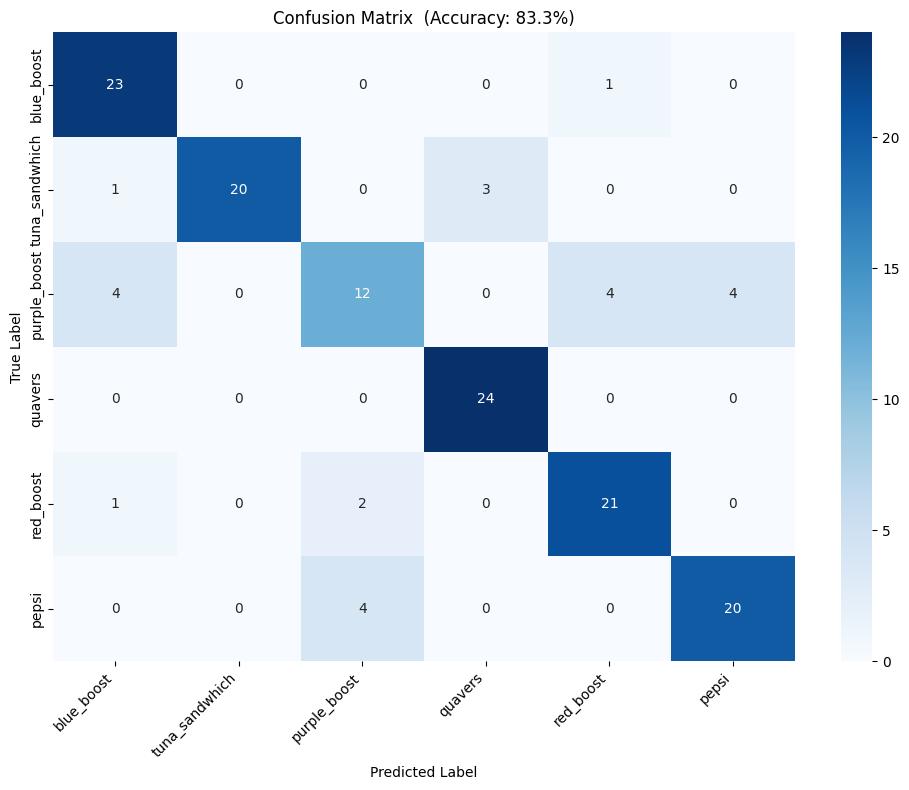

In [8]:
import os
import numpy as np
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Configuration ────────────────────────────────────────────────────────────
TRAIN_DIR = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/train"
TEST_DIR  = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/test"
IMG_SIZE  = (64, 64)   # resize all images to this

LABEL_MAP = {
    'blue_boost': 0,
    'tuna_sandwhich': 1,
    'purple_boost': 2,
    'quavers': 3,
    'red_boost': 4,
    'pepsi': 5
}
CLASS_NAMES = [k for k, _ in sorted(LABEL_MAP.items(), key=lambda x: x[1])]

# ─── Feature Extraction ───────────────────────────────────────────────────────
def extract_features(img_path, size=IMG_SIZE):
    
    img = Image.open(img_path).convert("RGB").resize(size)
    return np.array(img).flatten().astype(np.float32) / 255.0


def load_dataset(root_dir):
    X, y = [], []
    for class_name, label in LABEL_MAP.items():
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"  [WARNING] folder not found: {class_dir}")
            continue
        images = [f for f in os.listdir(class_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        print(f"  {class_name}: {len(images)} images")
        for fname in images:
            path = os.path.join(class_dir, fname)
            try:
                features = extract_features(path)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"    [SKIP] {fname}: {e}")
    return np.array(X), np.array(y)


# ─── Load Data ────────────────────────────────────────────────────────────────
print("Loading training data...")
X_train, y_train = load_dataset(TRAIN_DIR)
print(f"  → {X_train.shape[0]} samples, {X_train.shape[1]} features\n")

print("Loading test data...")
X_test, y_test = load_dataset(TEST_DIR)
print(f"  → {X_test.shape[0]} samples\n")

# ─── Train Random Forest ──────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf.fit(X_train, y_train)
print("Training complete.\n")

# ─── Evaluate ─────────────────────────────────────────────────────────────────
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix  (Accuracy: {acc*100:.1f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
